In [2]:
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty.skeleton import Skeleton
import os
import pickle
import matplotlib.pyplot as plt
import myelin_analysis
import plotly.express as px
from lookup_activity_by_pt_root_id import *

#for debugging
import importlib


In [ ]:
'''Interareal Conduction Delay Analysis.
Logic:

SELECT POPULATION OF NEURONS IN V1.

Create a bounding box around a column in V1. 
(Perhaps take all the neurons in the highly proofread column.)


Then, decide a bounding box in the target higher order visual area.
For each neuron, get it's synapses. 
Only consider neurons that have at least 10 (perhaps change) synapses whose postsynaptic nuclei sit in the bounding area.

Then, want to save such a synapse table with information about:
- presynaptic pt_root_id
- postsynaptic pt_root_id
- presynaptic cell type
- postsynaptic cell type
- presynaptic synapse x,y,z voxel position ???
- postsynaptic synapse x,y,z voxel position ???? (determine based on the functions we build).
- maybe some other info.

Then, want to make sure we have myelin traces for all the neurons we are considering.
If not, extract them...

Next: get the estimated delays to each synapse.

Can plot by cell type, etc. Maybe create a plot that shows distribution of delays, also plotted by position in the recipient column.


Now we have a population of presynaptic pt_root_ids, as well as a population of postsynaptic pt_root_ids.
As well as delays to each synapse.


FIRST ANALYSIS: COMPARE DELAYS:
    1. Get delay distribution, as well as time saved by myelination.
    2. Delays by amount of myelin maybe????
    3. Delay distribution for population of BC's / MC's that are hit.
    Goal to see if adding myelin can make neurons significantly faster.
    If there is a significant difference between neurons for time from spike to activating neurons in higher area. 


Now let's look at disynaptic inhibition:
    First, let's look at all the synapses onto 


'''

In [3]:
client = CAVEclient('minnie65_public')
client.version = 1507
cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')

In [4]:
#RUN WHENEVER WE HAVE NEW MYELIN EXTRACTED.
#Extract and save synapse info and delays for all neurons that we have myelin for.

importlib.reload(myelin_analysis) #delete this later....

directory_segs_myelin = 'segments_myelin_1507'
directory_synapse_len_delay = 'synapse_len_delay_1507'

#Get pt_root_ids of interest.
pt_root_ids = []
for filename in os.listdir(directory_segs_myelin):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        pt_root_ids.append(pt_root_id)

myelin_analysis.create_synapse_len_delay_df_all_neurons(pt_root_ids, client, cell_type_df, directory_segs_myelin, directory_synapse_len_delay, overwrite = False)




Processing neuron 864691135739733140
File 864691135739733140.pkl already exists. Skipping...
Processing neuron 864691136041000190
File 864691136041000190.pkl already exists. Skipping...
Processing neuron 864691135938604804
File 864691135938604804.pkl already exists. Skipping...
Processing neuron 864691136578982164
File 864691136578982164.pkl already exists. Skipping...
Processing neuron 864691135209715577
File 864691135209715577.pkl already exists. Skipping...
Processing neuron 864691135700409211
File 864691135700409211.pkl already exists. Skipping...
Processing neuron 864691136176327430
File 864691136176327430.pkl already exists. Skipping...
Processing neuron 864691136313301565
Number of synapses for 864691136313301565:  509


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:271: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapses_len_delay_df = pd.concat([


Processing neuron 864691135417236410
File 864691135417236410.pkl already exists. Skipping...
Processing neuron 864691135101521952
Number of synapses for 864691135101521952:  401


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:271: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapses_len_delay_df = pd.concat([


Processing neuron 864691135431089968
Number of synapses for 864691135431089968:  679


...

Processing neuron 864691135469753426
File 864691135469753426.pkl already exists. Skipping...
Processing neuron 864691136974813212
File 864691136974813212.pkl already exists. Skipping...
Processing neuron 864691135640325435
Number of synapses for 864691135640325435:  460


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:271: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapses_len_delay_df = pd.concat([


Processing neuron 864691135480311494
Number of synapses for 864691135480311494:  952


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:271: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapses_len_delay_df = pd.concat([


Processing neuron 864691135384176602
File 864691135384176602.pkl already exists. Skipping...
Processing neuron 864691136195284556
File 864691136195284556.pkl already exists. Skipping...
Processing neuron 864691136195419606
File 864691136195419606.pkl already exists. Skipping...
Processing neuron 864691135106110285
File 864691135106110285.pkl already exists. Skipping...
Processing neuron 864691135570534534
File 864691135570534534.pkl already exists. Skipping...
Processing neuron 864691136124845606
File 864691136124845606.pkl already exists. Skipping...


In [16]:
print([1246472,  479656,  815440] //np.array([4,4,40]))

[311618 119914  20386]


In [3]:
#TO TEST unpickle first file in synapse_len_delay_1507
with open(os.path.join(directory_synapse_len_delay, os.listdir(directory_synapse_len_delay)[1]), 'rb') as f:
    syn_df = pickle.load(f)
syn_df.head()

NameError: name 'directory_synapse_len_delay' is not defined

In [3]:
column_df = client.materialize.query_table('allen_v1_column_types_slanted_ref')

#print list of pt_root_ids in column_df
print(column_df['pt_root_id'].tolist())

print(len(column_df))

[864691136021936376, 864691135164434989, 864691135778141101, 864691135694415551, 864691135778773856, 864691136453183487, 864691135911348649, 864691136006493898, 864691135849706078, 864691135503287618, 864691135741655956, 864691136228491601, 864691134886912506, 864691136674275975, 864691135566089495, 864691135763447862, 864691135697785242, 864691135868319254, 864691135448518996, 864691136913261297, 864691136006519498, 864691135954393891, 864691135294520844, 864691135919854768, 864691135492773607, 864691135993550529, 864691136905758130, 864691135566109463, 864691135615661771, 864691136025624889, 864691136927176778, 864691136195891788, 864691135809280541, 864691135518041555, 864691135940881830, 864691135719916081, 864691135640672571, 864691135685980087, 864691136674080135, 864691135867644805, 864691136813414003, 864691135431089968, 864691136389688695, 864691135591725067, 864691135518791818, 864691135476581440, 864691135725842603, 864691136057790424, 864691134949081852, 864691135398243105,

In [9]:
#check if 864691136144674612 exists in segments_myelin_1507 directory.
print(864691135996497834 in pt_root_ids)

NameError: name 'pt_root_ids' is not defined

# Visualize synapse positions in space

In [4]:
#1. Figure out how many of our neurons are located in allen_v1_column_types_slanted_ref

# See how many pt_root_ids in synapse_len_delay_1507 are also in column_df
count = 0
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in column_df['pt_root_id'].tolist():
            count += 1
print(count)

222


In [5]:
#2. Combine all the synapse_len_delay_1507 files that are in column_df into a single dataframe.
synapse_delay_list = []

for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in column_df['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

print(len(synapse_delay_df))

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavio

163716


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_40005/777693655.py:11: FutureWarning: The behavio

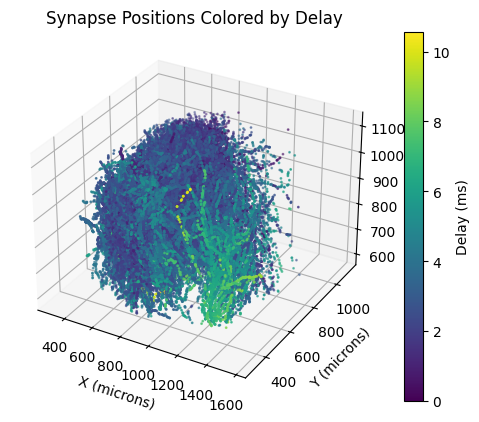

In [7]:
#3. Create 3d scatter plot of synapse positions, colored by delay. 'pre_pt_position', a column of synapse_delay_df is a list of [x,y,z]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(synapse_delay_df['pre_pt_position'].apply(lambda x: x[0]),
                synapse_delay_df['pre_pt_position'].apply(lambda x: x[1]),
                synapse_delay_df['pre_pt_position'].apply(lambda x: x[2]),
                c=synapse_delay_df['delay'], cmap='viridis', s=1)
plt.colorbar(sc, label='Delay (ms)')
ax.set_xlabel('X (microns)')
ax.set_ylabel('Y (microns)')
ax.set_zlabel('Z (microns)')
plt.title('Synapse Positions Colored by Delay')
plt.show()


In [73]:
#3. Create 3d scatter plot of synapse positions, colored by delay.

# Convert positions into separate columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(synapse_delay_df['pre_pt_position'].tolist(), index=synapse_delay_df.index)

x_min, x_max = 1100, 1500
# x_min, x_max = 0, 1500

# Filter by X only
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_x_df,
    x='x', y='y', z='z',
    color='delay',
    color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    range_color=[2, 6]
    # range_color=[0, 2]
)

fig.update_traces(marker=dict(size=2))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay'
)

fig.show()

In [ ]:
#3.05 IN PROGRESS Create 3d scatter plot of synapse positions, colored by delay/distance from soma.

# Convert positions into separate columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(synapse_delay_df['pre_pt_position'].tolist(), index=synapse_delay_df.index)

x_min, x_max = 1100, 1500
# x_min, x_max = 0, 1500

# Filter by X only
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_x_df,
    x='x', y='y', z='z',
    color='delay',
    color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    range_color=[2, 6]
    # range_color=[0, 2]
)

fig.update_traces(marker=dict(size=2))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay'
)

fig.show()

In [48]:
#3.1 Create 3d scatter plot of synapse positions, colored by delay unmyelin.

import plotly.express as px

# Convert positions into separate columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(synapse_delay_df['pre_pt_position'].tolist(), index=synapse_delay_df.index)


x_min, x_max = 1100, 1500
filtered_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]  


#filter based on cell type to include. cell_type_df has for pt_root_id, and use pre_pt_root_id in synapse_delay_df
# Example: only include if cell type is 23P
# cell_types_to_include = ['23P']  # Example cell types
# pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
# filtered_df = synapse_delay_df[synapse_delay_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_df,
    x='x', y='y', z='z',
    # color='delay_unmyelin',
    color = 'delay',
    # color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    range_color=[0, 7]
)

fig.update_traces(marker=dict(size=1))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay'
)

fig.show()

In [74]:
#3.2 Try doing it with difference between delay and unmyelinated delay.

# Expand positions into x, y, z columns
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(
    synapse_delay_df['pre_pt_position'].tolist(),
    index=synapse_delay_df.index
)

# Create new column for difference
synapse_delay_df['delay_diff'] = synapse_delay_df['delay_unmyelin'] - synapse_delay_df['delay']

x_min, x_max = 1100, 1500
# x_min, x_max = 0, 1500

# Filter by X only
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

fig = px.scatter_3d(
    # synapse_delay_df,
    filtered_x_df,
    x='x', y='y', z='z',
    color='delay_diff',
    color_continuous_scale='viridis',
    size_max=2, opacity=0.7,
    # range_color=[2, 6]
    range_color=[0, 2]
)

fig.update_traces(marker=dict(size=2))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    title='Synapse Positions Colored by Delay Difference (unmyel - delay)',
    coloraxis_colorbar=dict(title="Delay Difference (ms)")
)

fig.show()


In [50]:
# Find number of unique "pre_pt_root_id" in synapse_delay_df that have delay_diff > 3

# Filter rows where delay_diff > thresh
thresh = 1.5
filtered = synapse_delay_df[synapse_delay_df['delay_diff'] > thresh]

# Count unique pre_pt_root_id
unique_count = filtered['pre_pt_root_id'].nunique()

print(f'Number of unique pre_pt_root_id with delay_diff > {thresh}: {unique_count}')

#print those root ids
unique_root_ids = filtered['pre_pt_root_id'].unique()
print("Unique pre_pt_root_id with delay > 3:", unique_root_ids)


Number of unique pre_pt_root_id with delay_diff > 1.5: 32
Unique pre_pt_root_id with delay > 3: [864691135417236410 864691135356753871 864691135105897037
 864691135655526082 864691134966005023 864691136330407914
 864691136664845278 864691136389875831 864691136144674612
 864691136040977662 864691135464263742 864691135479830982
 864691135476495936 864691135756145106 864691136195566294
 864691135953669667 864691136618553563 864691137055290998
 864691135489677882 864691135503182685 864691135489514810
 864691135163673901 864691135617152361 864691136093003700
 864691135350542039 864691135496268176 864691136579098388
 864691136335150259 864691135911301033 864691136991202453
 864691135726140843 864691135911679145]


In [70]:
#3.3 Plot only synapses with large delay difference. (NOW it's about excit inhib.)

# Filter only synapses where delay_diff > thresh

thresh_diff = 1.5

x_min, x_max = 0, 1500
# x_min, x_max = 0, 1500


# filtered_df = synapse_delay_df[synapse_delay_df['delay_diff'] > thresh_diff]
# filtered_df = synapse_delay_df[synapse_delay_df['delay'] > 3]

filtered_df = synapse_delay_df[
    (synapse_delay_df['delay'] >= 0) & (synapse_delay_df['delay'] <= 100)
]


filtered_df = filtered_df[
    (filtered_df['x'] >= x_min) & (filtered_df['x'] <= x_max)
].copy()

# Remove unknown synapses
filtered_df = filtered_df[
    filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

#filter based on cell type to include. cell_type_df has for pt_root_id, and use pre_pt_root_id in synapse_delay_df
# Example: only include if cell type is 23P
cell_types_to_include = ['4P']  # Example cell types
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()

filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

# #Now filter for only one random pt_root_id, selected from the unique root ids in filtered_df
# #pick one random pt_root_id
# import random
# random_pt_root_id = random.choice(filtered_df['pre_pt_root_id'].unique())
# filtered_df = filtered_df[filtered_df['pre_pt_root_id'] == random_pt_root_id]



#print number of excitatory and inhibitory synapses in filtered_df
print("Number of excitatory synapses:", (filtered_df['post_excit_inhib'] == 'excitatory_neuron').sum())
print("Number of inhibitory synapses:", (filtered_df['post_excit_inhib'] == 'inhibitory_neuron').sum())
print('ratio of exc to inh:', (filtered_df['post_excit_inhib'] == 'excitatory_neuron').sum() / (filtered_df['post_excit_inhib'] == 'inhibitory_neuron').sum())

# 3D scatter plot, colored by delay difference
fig = px.scatter_3d(
    filtered_df,
    x='x', y='y', z='z',
    color='post_excit_inhib',
    color_discrete_map={'excitatory_neuron': 'blue', 'inhibitory_neuron': 'red'},
    # color_continuous_scale='RdBu',
    # color_continuous_scale='viridis',
    opacity=0.7,
    size_max=4
)

fig.update_traces(marker=dict(size=1))  # smaller points
fig.update_layout(
    scene=dict(
        xaxis_title='X (microns)',
        yaxis_title='Y (microns)',
        zaxis_title='Z (microns)'
    ),
    # title= f'Synapse Positions (delay_diff > {thresh_diff} ms)',
    coloraxis_colorbar=dict(title="Delay Difference (ms)")
)

fig.show()



Number of excitatory synapses: 9491
Number of inhibitory synapses: 3250
ratio of exc to inh: 2.9203076923076923


In [214]:
#3.33_intermission Let's look at how ratio of excitatory to inhibitory synapses changes with delay of synapses.
#Do this for a given set of cell types: ["23P", "4P", "5P-IT", "5P-ET", "BC", "MC"]
#Want bins of .5 milliseconds. So 0 - .5, .5 - 1, 1 - 1.5, etc.
#For each bin, for each cell type (different color for each) put a point for ratio of exc to inh synapses.


cell_types_to_include = ["23P", "4P", "5P-IT", "5P-ET", "BC", "MC"]

# Get pt_root_ids for the included cell types
pt_root_ids_to_include = cell_type_df[
    cell_type_df["cell_type"].isin(cell_types_to_include)
][["pt_root_id", "cell_type"]]

# Merge to attach cell type to each synapse
merged_df = synapse_delay_df.merge(
    pt_root_ids_to_include, how="inner", left_on="pre_pt_root_id", right_on="pt_root_id"
)

# Remove unknown synapses
merged_df = merged_df[
    merged_df["post_excit_inhib"].isin(["excitatory_neuron", "inhibitory_neuron"])
]

# Define delay bins (0.5 ms bins)
bin_edges = np.arange(0, merged_df["delay"].max() + 0.5, 0.5)
merged_df["delay_bin"] = pd.cut(merged_df["delay"], bins=bin_edges, right=False)

# Compute ratio of excitatory to inhibitory per bin per cell type
ratio_df = (
    merged_df.groupby(["cell_type", "delay_bin"])["post_excit_inhib"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Compute ratio safely (avoid division by zero)
ratio_df["exc_to_inh_ratio"] = ratio_df.apply(
    lambda row: row.get("excitatory_neuron", 0)
    / row.get("inhibitory_neuron", np.nan)
    if row.get("inhibitory_neuron", 0) > 0
    else np.nan,
    axis=1,
)

# Midpoints for plotting
ratio_df["delay_bin_center"] = ratio_df["delay_bin"].apply(lambda x: x.mid)

# Plot: excitatory/inhibitory ratio vs. delay bin, colored by cell type
fig = px.scatter(
    ratio_df,
    x="delay_bin_center",
    y="exc_to_inh_ratio",
    color="cell_type",
    title="Excitatory/Inhibitory Synapse Ratio vs. Delay (per Cell Type)",
    labels={
        "delay_bin_center": "Delay (ms)",
        "exc_to_inh_ratio": "Exc/Inh Ratio",
    },
)

fig.update_traces(mode="markers+lines")
fig.update_layout(
    xaxis=dict(tickmode="linear", tick0=0, dtick=0.5,range=[0, 6]),
    yaxis=dict(title="Excitatory/Inhibitory Ratio", rangemode="tozero",range=[0, 13]),
    # yaxis=dict(title="Excitatory/Inhibitory Ratio", rangemode="tozero",range=[-1, 1.5],type="log"),
)
fig.show()


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_7784/2682629374.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [76]:
#3.35 Above thresh one color - orange, below another, purple

thresh_diff = 1
# x_min, x_max = 800, 1500
x_min, x_max = 0, 1500

# Filter to X range first
filtered_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
].copy()

# #filter based on cell type to include. cell_type_df has for pt_root_id, and use pre_pt_root_id in synapse_delay_df
# # Example: only include if cell type is 23P
# cell_types_to_include = ['23P']  # Example cell types
# pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
# filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

# Add category column based on threshold
filtered_df['diff_category'] = filtered_df['delay_diff'].apply(
    lambda x: 'above' if x > thresh_diff else 'below'
)

# #print neurons above thresh
# print(filtered_df[filtered_df['diff_category'] == 'above']['pre_pt_root_id'].unique())

# 3D scatter plot with discrete colors
fig = px.scatter_3d(
    filtered_df,
    x='x', y='y', z='z',
    color='diff_category',
    color_discrete_map={'above': 'orange', 'below': 'purple'},
    opacity=0.7,
    size_max=2
)

fig.update_traces(marker=dict(size=1))
fig.update_layout(
    scene=dict(
        xaxis_title="X (microns)",
        yaxis_title="Y (microns)",
        zaxis_title="Z (microns)"
    ),
    title=f'Synapse Positions (X in {x_min}-{x_max}, delay_diff threshold = {thresh_diff} ms)'
)

fig.show()


In [46]:
#3.37 Delay above or below a threshold, orange is fast, purple is slow


thresh_delay = 5
x_min, x_max = 1100, 1500

# Filter to X range
filtered_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
].copy()

# Add category column based on delay threshold
filtered_df['delay_category'] = filtered_df['delay'].apply(
    lambda d: 'below' if d < thresh_delay else 'above'
)

# 3D scatter plot with discrete colors
fig = px.scatter_3d(
    filtered_df,
    x='x', y='y', z='z',
    color='delay_category',
    color_discrete_map={'below': 'orange', 'above': 'purple'},
    opacity=0.7,
    size_max=2
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(
    scene=dict(
        xaxis_title="X (microns)",
        yaxis_title="Y (microns)",
        zaxis_title="Z (microns)"
    ),
    title=f'Synapse Positions (X in {x_min}-{x_max}, delay threshold = {thresh_delay} ms)'
)

fig.show()


In [91]:
#3.4 Separate color for excitatory vs inhibitory synapse.

# Expand positions into x, y, z
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(
    synapse_delay_df['pre_pt_position'].tolist(),
    index=synapse_delay_df.index
)

# Filter by X range
x_min, x_max = 1000, 1500
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

# Remove unknown synapses
filtered_x_df = filtered_x_df[
    filtered_x_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

# Define custom colors for the two classes
color_map = {
    "excitatory_neuron": "blue",
    "inhibitory_neuron": "red"
}

# Make plot
fig = px.scatter_3d(
    filtered_x_df,
    x="x", y="y", z="z",
    color="post_excit_inhib",
    color_discrete_map=color_map,
    opacity=0.7,
    size_max=2
)

fig.update_traces(marker=dict(size=1))
fig.update_layout(
    scene=dict(
        xaxis_title="X (microns)",
        yaxis_title="Y (microns)",
        zaxis_title="Z (microns)"
    ),
    title="Synapse Positions: Excitatory (yellow) vs Inhibitory (red)"
)

fig.show()

In [126]:
#3.41 Separate color for each cell type.

# Expand positions into x, y, z
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(
    synapse_delay_df['pre_pt_position'].tolist(),
    index=synapse_delay_df.index
)

# Filter by X range
x_min, x_max = 1100, 1500
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
].copy()

# Remove unknown cell types
filtered_x_df = filtered_x_df[filtered_x_df['post_cell_type'] != 'unknown']

#print unique pre_pt_rood_ids in filtered_x_df
print("Unique pre_pt_root_id in filtered data:", filtered_x_df['pre_pt_root_id'].nunique())
#also print, for each unique id, number of entries and average delay in one row, sorted by number of entries high to low.
unique_ids = filtered_x_df['pre_pt_root_id'].unique()
summary_list = []
for uid in unique_ids:
    subset = filtered_x_df[filtered_x_df['pre_pt_root_id'] == uid]
    count = len(subset)
    avg_delay = subset['delay'].mean()
    summary_list.append((uid, count, avg_delay))
summary_list.sort(key=lambda x: x[1], reverse=True)
print("pre_pt_root_id, count, avg_delay")
for row in summary_list:
    print(row)


# Make plot, one color per cell type
fig = px.scatter_3d(
    filtered_x_df,
    x="x", y="y", z="z",
    color="post_cell_type",   # categorical coloring
    opacity=0.7,
    size_max=2
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(
    scene=dict(
        xaxis_title="X (microns)",
        yaxis_title="Y (microns)",
        zaxis_title="Z (microns)"
    ),
    title="Synapse Positions by Post Cell Type (excluding unknown)"
)

fig.show()


Unique pre_pt_root_id in filtered data: 58
pre_pt_root_id, count, avg_delay
(864691135778700477, 651, np.float64(6.413588885112952))
(864691136664845278, 352, np.float64(3.017710691994409))
(864691136108071129, 346, np.float64(4.4695926762257665))
(864691135476495936, 330, np.float64(4.012755581178653))
(864691135938604804, 273, np.float64(4.506322947050426))
(864691135350542039, 246, np.float64(5.118353121492851))
(864691135496268176, 223, np.float64(4.728653231678101))
(864691135701676411, 201, np.float64(4.16921321718995))
(864691136195889622, 167, np.float64(5.7189867823124))
(864691136974813212, 166, np.float64(4.751228931947765))
(864691135970210661, 158, np.float64(5.788517696746167))
(864691135274038801, 157, np.float64(3.3713709559878633))
(864691136144674612, 156, np.float64(3.5809123993947525))
(864691136093003700, 152, np.float64(5.1041426708530775))
(864691136991202453, 146, np.float64(1.79251277295832))
(864691135726140843, 143, np.float64(3.8481775256157458))
(8646911366

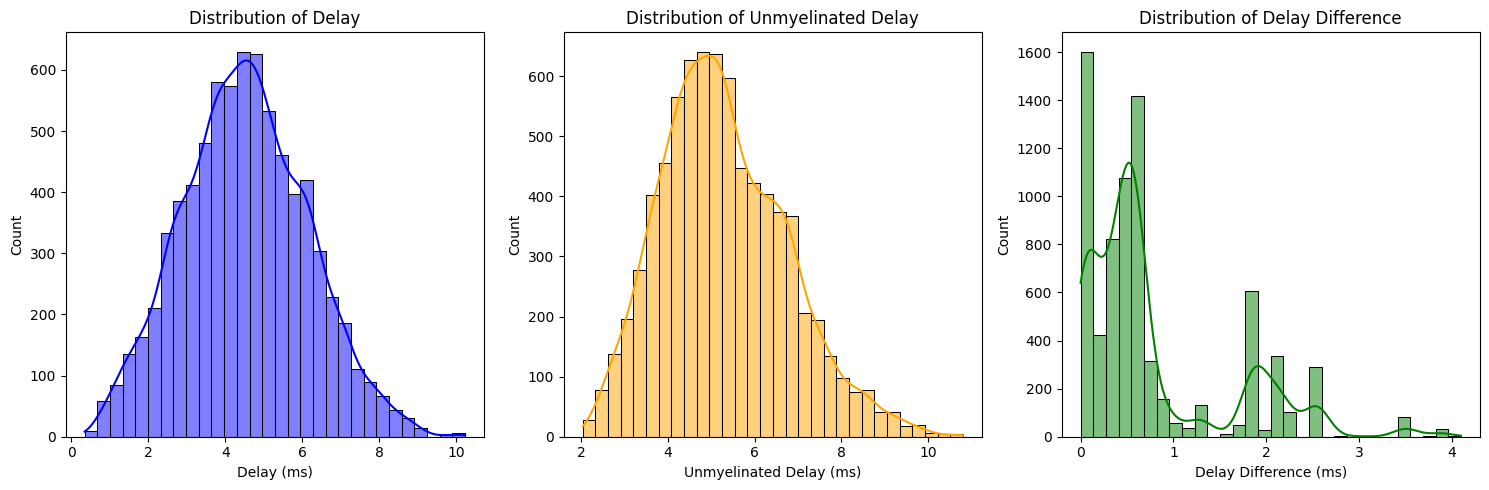

In [59]:
#4.0 Plot distribution of delay, distribution of delay_unmyelin, and distribution of delay_diff, for filtered x range (1100-1500)
import seaborn as sns
import matplotlib.pyplot as plt

# Filter by X range
x_min, x_max = 1100, 1500
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(filtered_x_df['delay'], bins=30, kde=True, color='blue')
plt.title('Distribution of Delay')
plt.xlabel('Delay (ms)')
plt.ylabel('Count')
plt.subplot(1, 3, 2)
sns.histplot(filtered_x_df['delay_unmyelin'], bins=30, kde=True, color='orange')
plt.title('Distribution of Unmyelinated Delay')
plt.xlabel('Unmyelinated Delay (ms)')
plt.ylabel('Count')
plt.subplot(1, 3, 3)
sns.histplot(filtered_x_df['delay_diff'], bins=30, kde=True, color='green')
plt.title('Distribution of Delay Difference')
plt.xlabel('Delay Difference (ms)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



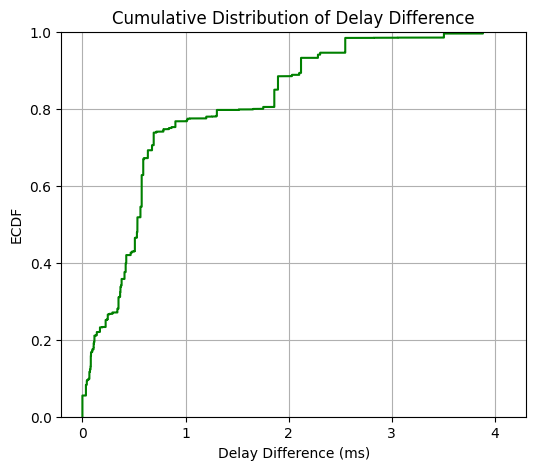

In [70]:
#4.05 Make also a cumulative distribution function (CDF) plot for the distribution of delay diff.

# Filter by X range
x_min, x_max = 1100, 1500
filtered_x_df = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]
plt.figure(figsize=(6, 5))
sns.ecdfplot(filtered_x_df['delay_diff'], color='green')
plt.title('Cumulative Distribution of Delay Difference')
plt.xlabel('Delay Difference (ms)')
plt.ylabel('ECDF')
plt.grid()
plt.show()

# Visualizing Activity Traces

In [5]:
coreg_df = client.materialize.query_table('coregistration_manual_v4')



In [48]:
#load myelin_info_df.csv

myelin_info_df = pd.read_csv('myelin_info_df.csv')
myelin_info_df.head()

,pt_root_id,total_myelin_length,cell_type,number_of_segments
0,864691135938604804,279.49,23P,104
1,864691136578982164,0.00,4P,69
2,864691136196131542,186.98,23P,73
3,864691135572346349,511.41,5P-IT,49
4,864691135699487522,153.43,MC,789


In [200]:
#start loading pt_root_ids.

# pt_root_ids = [864691135163673901, 864691136991202453]

pt_root_ids = [864691135955081992,864691136380268245, 864691135479592902, 864691135993150913]

# directory_segs_myelin = 'segments_myelin_1507'

# Get pt_root_ids of interest.
# pt_root_ids = []
# for filename in os.listdir(directory_segs_myelin):
#     if filename.endswith('.pkl'):
#         pt_root_id = int(filename.split('.')[0])
#         pt_root_ids.append(pt_root_id)

results_df = lookup_activity_by_pt_root_ids(pt_root_ids, coreg_df, "microns_activity/", True)


Found 3 matches for 4 pt_root_ids
  - Spanning 2 sessions
  - Spanning 2 scans
Processing scan_6_7_coreg.zip (1 units to extract)...
Processing scan_9_4_coreg.zip (2 units to extract)...

Extracted 3 units


In [134]:
results_df.iloc[0:20]

,pt_root_id,unit_id,session,scan_idx,nframes,fps,spike_trace,calcium_trace
0,864691135955081992,1181,6,7,40000.0,6.3009,"[6.3511725e-09, 9.548227e-09, 9.876761e-09, 8....","[5.3961263, 21.176113, 33.607563, 17.520954, 1..."


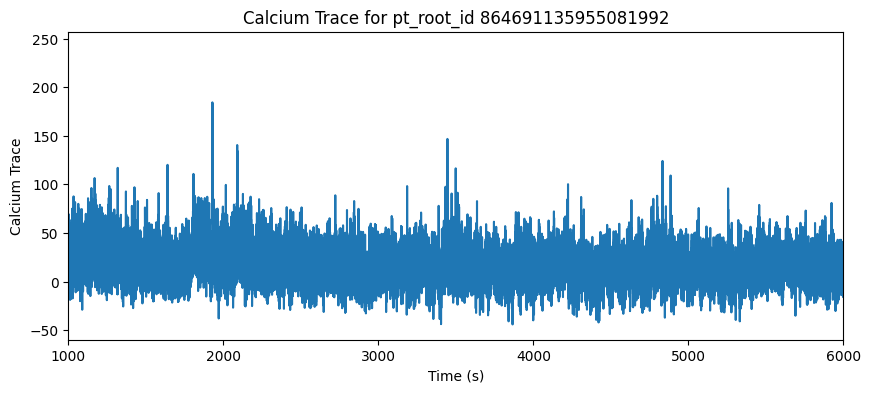

In [203]:
#0.1 plot "calcium trace" for idx in results_df, with given nframes, fps, seconds as time, over given t_range

idx = 0
t_range = (1000, 6000)  # seconds

nframes = results_df.iloc[idx]['nframes']
fps = results_df.iloc[idx]['fps']
seconds = np.arange(nframes) / fps
trace = results_df.iloc[idx]['calcium_trace']
plt.figure(figsize=(10, 4))
plt.plot(seconds, trace)
plt.xlim(t_range)
plt.xlabel('Time (s)')
plt.ylabel('Calcium Trace')
plt.title(f"Calcium Trace for pt_root_id {results_df.iloc[idx]['pt_root_id']}")
plt.show()


In [1]:
#0.1 plot "calcium trace" for idx in results_df, with given nframes, fps, seconds as time, over given t_range
# Plot idx_range [start, end] traces one above the other in subplots. 

idx_range = (10, 30)  # plot traces from idx 0 to 4
# t_range = (5000, 7000)  # seconds
t_range = (1000, 2000)  # seconds
n_traces = idx_range[1] - idx_range[0]
nframes = results_df.iloc[0]['nframes']
fps = results_df.iloc[0]['fps']
seconds = np.arange(nframes) / fps
plt.figure(figsize=(10, 2 * n_traces))
for i in range(idx_range[0], idx_range[1]):

    #get from myelin_info_df, via pt_root_id, the total_myelin_length and cell_type
    pt_root_id = results_df.iloc[i]['pt_root_id']
    myelin_row = myelin_info_df[myelin_info_df['pt_root_id'] == pt_root_id]

    total_myelin_length = myelin_row['total_myelin_length'].values[0]
    cell_type = myelin_row['cell_type'].values[0]

    trace = results_df.iloc[i]['calcium_trace']
    #z score trace
    # trace = (trace - np.mean(trace)) / np.std(trace)

    plt.subplot(n_traces, 1, i - idx_range[0] + 1)
    plt.plot(seconds, trace)
    plt.xlim(t_range)
    plt.ylim(-200, 400)
    plt.xlabel('Time (s)')
    plt.ylabel('Calcium Trace')
    #For title, put pt_root_id, session, and scan_idx, and total_myelin_length and cell_type
    plt.title(f"pt_root_id {pt_root_id}, session {results_df.iloc[i]['session']}, scan_idx {results_df.iloc[i]['scan_idx']}, myelin {total_myelin_length:.1f} um, type {cell_type}")
plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined

# Prototype interareal activity/ delay analyses.

In [23]:
# 0.1 Prepare synapse_delay_df, and get pt_root_ids_v1, and pt_root_ids_hva

synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in column_df['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

print("Number of synapses in synapse_delay_df:", len(synapse_delay_df))

#CREATE NEW COLUMNS IN SYNAPSE_DELAY_DF
synapse_delay_df['delay_diff'] = synapse_delay_df['delay_unmyelin'] - synapse_delay_df['delay']
synapse_delay_df[['x', 'y', 'z']] = pd.DataFrame(synapse_delay_df['pre_pt_position'].tolist(), index=synapse_delay_df.index)

#GET ONLY SYNAPSES IN HVA. IE x range 1100-1500
x_min, x_max = 1100, 1500
synapse_delay_df_hva = synapse_delay_df[
    (synapse_delay_df['x'] >= x_min) & (synapse_delay_df['x'] <= x_max)
]

print("Number of synapses in synapse_delay_df_hva:", len(synapse_delay_df_hva))

#collect pt_root_ids_v1
pt_root_ids_v1 = synapse_delay_df_hva['pre_pt_root_id'].unique().tolist()
print("Number of unique pre_synaptic pt_root_ids:", len(pt_root_ids_v1))

#collect pt_root_ids_hva
pt_root_ids_hva = synapse_delay_df_hva['post_pt_root_id'].unique().tolist()

#Only keep pt_root_ids_hva where post_cell_type is not unknown, or astrocyte, or microglia, etc.
cell_types_to_exclude = ['unknown', 'astrocyte', 'microglia', 'oligo','NGC', 'OPC','pericyte']

pt_root_ids_hva = synapse_delay_df_hva[
    ~synapse_delay_df_hva['post_cell_type'].isin(cell_types_to_exclude)
]['post_pt_root_id'].unique().tolist()
print("Number of unique (neural) post_synaptic pt_root_ids:", len(pt_root_ids_hva))

#Get cell types for all pt_root_ids in pt_root_ids_v1, and print number of counts for each cell type.
cell_type_v1 = cell_type_df[cell_type_df['pt_root_id'].isin(pt_root_ids_v1)]
print(cell_type_v1['cell_type'].value_counts())

#Get cell types for all pt_root_ids in pt_root_ids_hva, and print number of counts for each cell type.
cell_type_hva = cell_type_df[cell_type_df['pt_root_id'].isin(pt_root_ids_hva)]
print(cell_type_hva['cell_type'].value_counts())


# #Print number of pt_root_ids for each post_cell_type, besides the ones we exclude.
# print(synapse_delay_df_hva[~synapse_delay_df_hva['post_cell_type'].isin(cell_types_to_exclude)]['post_cell_type'].value_counts())


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_92649/1879033101.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_92649/1879033101.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_92649/1879033101.py:11: FutureWarning: The beha

Number of synapses in synapse_delay_df: 145700
Number of synapses in synapse_delay_df_hva: 8571
Number of unique pre_synaptic pt_root_ids: 124
Number of unique (neural) post_synaptic pt_root_ids: 4189
cell_type
23P      54
5P-IT    33
4P       14
6P-IT     9
6P-CT     6
5P-ET     5
MC        3
BPC       1
Name: count, dtype: int64
cell_type
23P          1393
4P            656
5P-IT         509
BC            445
6P-IT         360
5P-ET         275
MC            257
6P-CT         200
BPC            58
5P-NP          36
astrocyte       5
OPC             4
oligo           3
microglia       1
Name: count, dtype: int64


In [24]:
#0.2 Prepare activity traces for pt_root_ids_v1 and pt_root_ids_hva.

coreg_df = client.materialize.query_table('coregistration_manual_v4')

activity_v1_df = lookup_activity_by_pt_root_ids(pt_root_ids_v1, coreg_df, "microns_activity/", True)
activity_hva_df = lookup_activity_by_pt_root_ids(pt_root_ids_hva, coreg_df, "microns_activity/", True)

#add cell type to activity_v1_df and activity_hva_df
activity_v1_df = activity_v1_df.merge(cell_type_df[['pt_root_id', 'cell_type']], on='pt_root_id', how='left')
activity_hva_df = activity_hva_df.merge(cell_type_df[['pt_root_id', 'cell_type']], on='pt_root_id', how='left')


Found 80 matches for 124 pt_root_ids
  - Spanning 6 sessions
  - Spanning 13 scans
Processing scan_4_7_coreg.zip (10 units to extract)...
Processing scan_5_6_coreg.zip (7 units to extract)...
Processing scan_5_7_coreg.zip (4 units to extract)...
Processing scan_6_2_coreg.zip (6 units to extract)...
Processing scan_6_4_coreg.zip (7 units to extract)...
Processing scan_6_6_coreg.zip (4 units to extract)...
Processing scan_6_7_coreg.zip (5 units to extract)...
Processing scan_7_3_coreg.zip (1 units to extract)...
Processing scan_7_4_coreg.zip (7 units to extract)...
Processing scan_8_5_coreg.zip (11 units to extract)...
Processing scan_9_3_coreg.zip (2 units to extract)...
Processing scan_9_4_coreg.zip (14 units to extract)...
Processing scan_9_6_coreg.zip (2 units to extract)...

Extracted 80 units
Found 1646 matches for 4189 pt_root_ids
  - Spanning 6 sessions
  - Spanning 15 scans
Processing scan_4_7_coreg.zip (121 units to extract)...
Processing scan_5_3_coreg.zip (58 units to extract

In [25]:
#For each session, scan_idx, print number of pt_root_ids of each cell type both in v1 and hva.

sessions = activity_v1_df['session'].unique()
for session in sessions:
    scan_idxs = activity_v1_df[activity_v1_df['session'] == session]['scan_idx'].unique()
    for scan_idx in scan_idxs:
        v1_subset = activity_v1_df[(activity_v1_df['session'] == session) & (activity_v1_df['scan_idx'] == scan_idx)]
        hva_subset = activity_hva_df[(activity_hva_df['session'] == session) & (activity_hva_df['scan_idx'] == scan_idx)]
        print(f"Session: {session}, Scan Index: {scan_idx}")
        print("V1 Cell Types:")
        print(v1_subset['cell_type'].value_counts())
        print("HVA Cell Types:")
        print(hva_subset['cell_type'].value_counts())
        print("\n")

Session: 4, Scan Index: 7
V1 Cell Types:
cell_type
23P      6
5P-ET    2
4P       2
Name: count, dtype: int64
HVA Cell Types:
cell_type
23P      80
4P       17
5P-ET    16
5P-IT     5
MC        3
Name: count, dtype: int64


Session: 5, Scan Index: 6
V1 Cell Types:
cell_type
4P       2
23P      2
5P-IT    2
6P-CT    1
Name: count, dtype: int64
HVA Cell Types:
cell_type
4P       35
23P      27
5P-IT    23
5P-ET    13
6P-IT     7
MC        1
6P-CT     1
Name: count, dtype: int64


Session: 5, Scan Index: 7
V1 Cell Types:
cell_type
4P       1
5P-IT    1
6P-CT    1
6P-IT    1
Name: count, dtype: int64
HVA Cell Types:
cell_type
4P       41
23P      30
5P-IT    23
5P-ET    12
6P-IT     7
6P-CT     1
Name: count, dtype: int64


Session: 6, Scan Index: 2
V1 Cell Types:
cell_type
23P      3
5P-IT    3
Name: count, dtype: int64
HVA Cell Types:
cell_type
4P       41
23P      22
5P-IT    19
5P-ET     5
6P-IT     1
Name: count, dtype: int64


Session: 6, Scan Index: 4
V1 Cell Types:
cell_type
23P   

In [44]:
#Pick a session and scan_idx, 

session = 4
scan_idx = 7

v1_cell_type = '23P'
hva_cell_type = '23P'

#Filtered activity dfs for ONLY that session, scan_idx, and cell type(s)
filtered_activity_v1_df = activity_v1_df[(activity_v1_df['session'] == session) & (activity_v1_df['scan_idx'] == scan_idx) & (activity_v1_df['cell_type'] == v1_cell_type)]
filtered_activity_hva_df = activity_hva_df[(activity_hva_df['session'] == session) & (activity_hva_df['scan_idx'] == scan_idx) & (activity_hva_df['cell_type'] == hva_cell_type)]

#Now, from synapse_delay_df, want to create a table of synapses that connect the filtered v1 neurons to the filtered hva neurons. Rows, v1 pt_root_ids, columns: hva pt_root_ids, values: number of synapses, average delay and std of those synapses.
filtered_synapses = synapse_delay_df[
    (synapse_delay_df['pre_pt_root_id'].isin(filtered_activity_v1_df['pt_root_id'])) &
    (synapse_delay_df['post_pt_root_id'].isin(filtered_activity_hva_df['pt_root_id']))
]
print(len(filtered_synapses))

filtered_synapses.iloc[0:20]



5


,pre_pt_position,pre_pt_root_id,post_pt_root_id,post_cell_type,post_excit_inhib,size,path_len_from_soma,vector_from_soma,delay,delay_unmyelin,delay_diff,x,y,z
16337,"[1215.72, 520.6, 747.28]",864691136330407914,864691135270320293,23P,excitatory_neuron,2792,1325.815701,"[520.472, -97.73599999999999, -107.08000000000...",2.865918,6.215593,3.349675,1215.720,520.600,747.28
16480,"[1212.04, 511.36, 705.2]",864691136330407914,864691136444588931,23P,excitatory_neuron,1092,1370.368788,"[516.7919999999999, -106.976, -149.15999999999...",3.134738,6.484413,3.349675,1212.040,511.360,705.20
16536,"[1210.256, 506.424, 690.08]",864691136330407914,864691135848445022,23P,excitatory_neuron,17156,1387.602881,"[515.008, -111.91200000000003, -164.2799999999...",3.238724,6.588399,3.349675,1210.256,506.424,690.08
130164,"[1212.416, 524.928, 893.0]",864691135701676411,864691135754741453,23P,excitatory_neuron,10596,951.569951,"[474.67999999999995, -86.91200000000003, 1.159...",4.503550,5.178458,0.674908,1212.416,524.928,893.00
130548,"[1317.952, 530.496, 736.52]",864691135701676411,864691135517531786,23P,excitatory_neuron,38388,802.945682,"[580.216, -81.34400000000005, -155.32000000000...",4.596767,4.766855,0.170088,1317.952,530.496,736.52


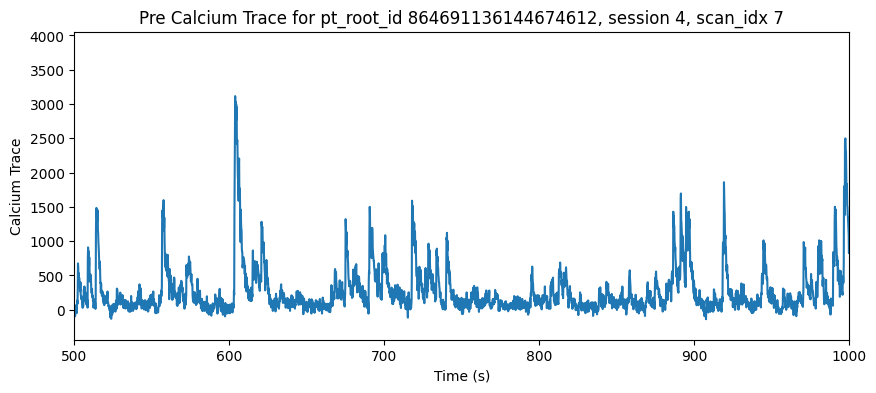

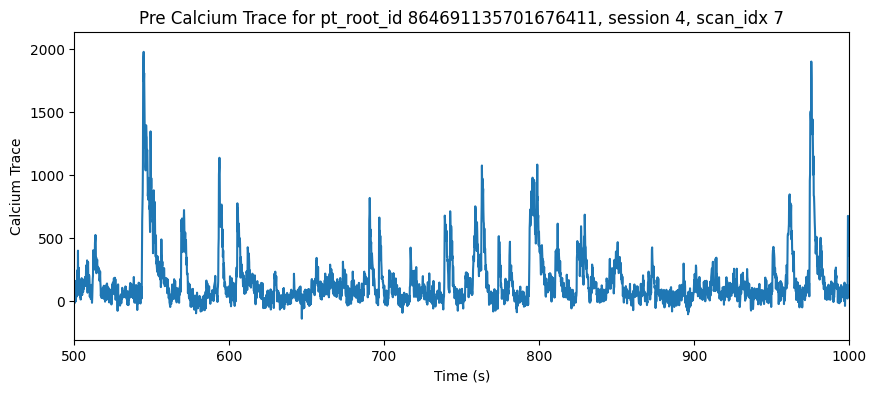

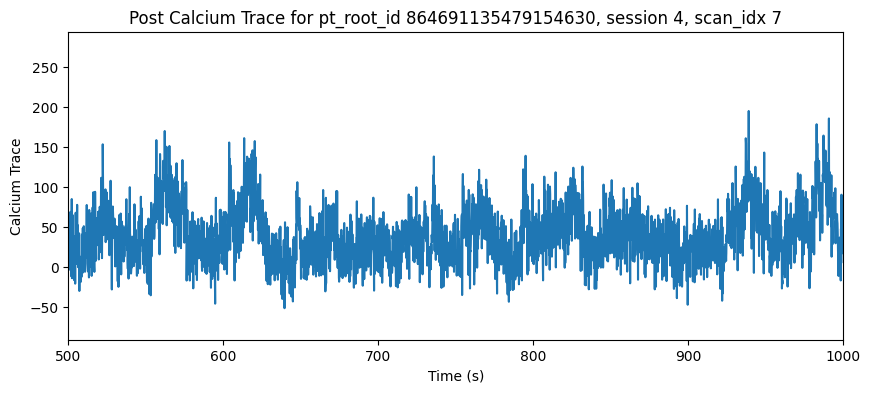

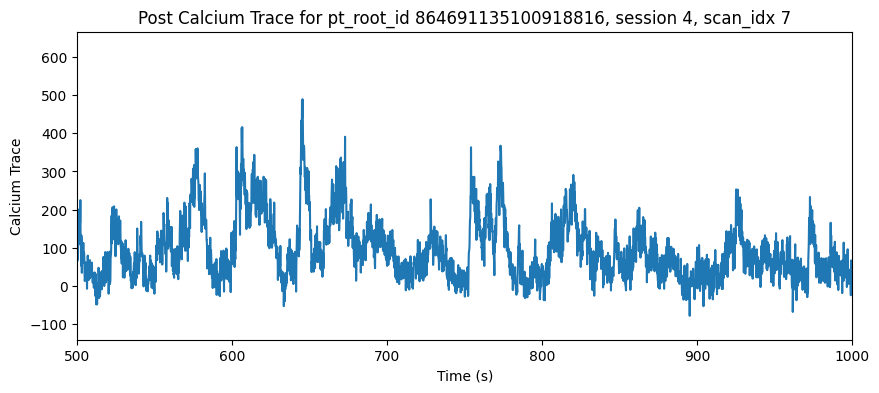

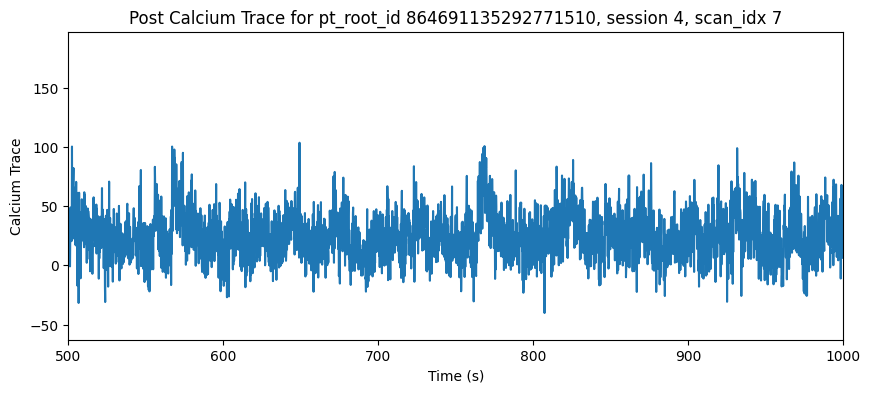

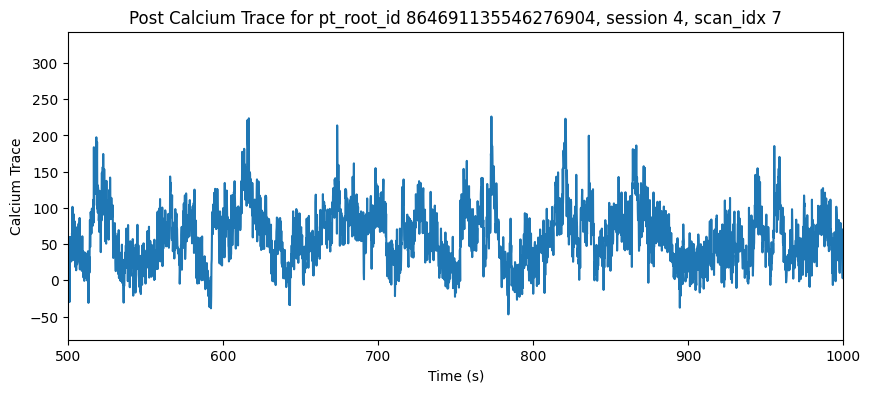

In [221]:
#1.2 Plot calcium traces of filtered_synapses, their pre, and post pt_root_ids. (plot pre first, then post)
# 
# ...for session/ scan_idx selection (above)

# session = 8
# scan_idx = 5
time_range = (500, 1000)

unique_pre_ids = filtered_synapses['pre_pt_root_id'].unique()
unique_post_ids = filtered_synapses['post_pt_root_id'].unique()

for pre_id in unique_pre_ids:
    pre_trace_row = filtered_activity_v1_df[filtered_activity_v1_df['pt_root_id'] == pre_id]
    if len(pre_trace_row) == 0:
        continue
    nframes = pre_trace_row.iloc[0]['nframes']
    fps = pre_trace_row.iloc[0]['fps']
    seconds = np.arange(nframes) / fps
    trace = pre_trace_row.iloc[0]['calcium_trace']
    plt.figure(figsize=(10, 4))
    plt.plot(seconds, trace)
    plt.xlim(time_range)
    plt.xlabel('Time (s)')
    plt.ylabel('Calcium Trace')
    plt.title(f"Pre Calcium Trace for pt_root_id {pre_id}, session {session}, scan_idx {scan_idx}")
    plt.show()
for post_id in unique_post_ids:
    post_trace_row = filtered_activity_hva_df[filtered_activity_hva_df['pt_root_id'] == post_id]
    if len(post_trace_row) == 0:
        continue
    nframes = post_trace_row.iloc[0]['nframes']
    fps = post_trace_row.iloc[0]['fps']
    seconds = np.arange(nframes) / fps
    trace = post_trace_row.iloc[0]['calcium_trace']
    plt.figure(figsize=(10, 4))
    plt.plot(seconds, trace)
    plt.xlim(time_range)
    plt.xlabel('Time (s)')
    plt.ylabel('Calcium Trace')
    plt.title(f"Post Calcium Trace for pt_root_id {post_id}, session {session}, scan_idx {scan_idx}")
    plt.show()

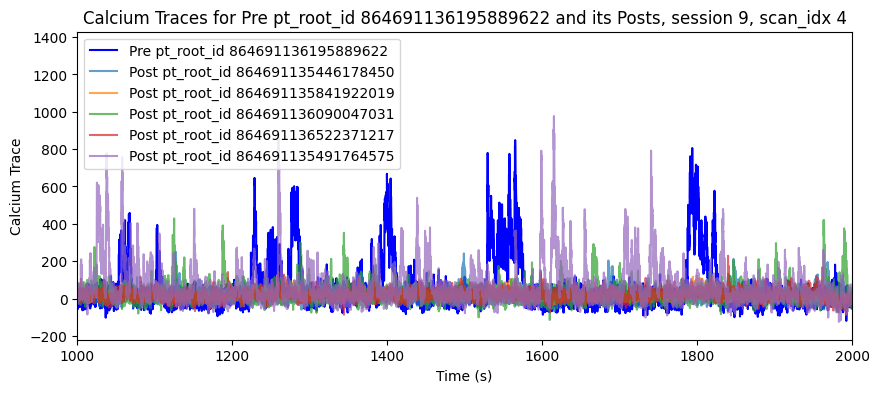

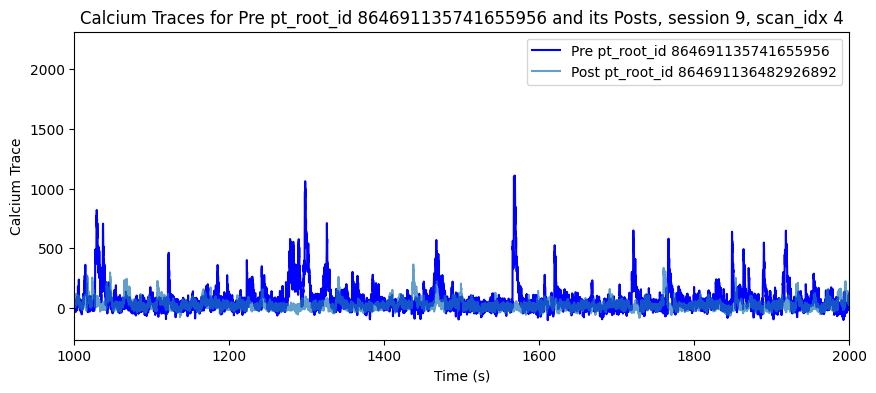

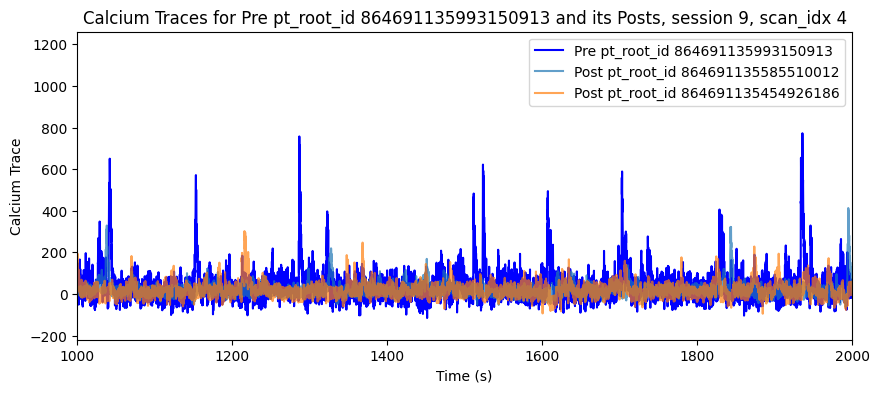

In [28]:
#Now same as above, but there is a separate plot for each pre pt_root_id, with all its post pt_root_ids traces on top of it.

time_range = (1000, 2000)
unique_pre_ids = filtered_synapses['pre_pt_root_id'].unique()
unique_post_ids = filtered_synapses['post_pt_root_id'].unique()
for pre_id in unique_pre_ids:
    pre_trace_row = filtered_activity_v1_df[filtered_activity_v1_df['pt_root_id'] == pre_id]
    if len(pre_trace_row) == 0:
        continue
    nframes = pre_trace_row.iloc[0]['nframes']
    fps = pre_trace_row.iloc[0]['fps']
    seconds = np.arange(nframes) / fps
    pre_trace = pre_trace_row.iloc[0]['calcium_trace']
    
    plt.figure(figsize=(10, 4))
    plt.plot(seconds, pre_trace, label=f"Pre pt_root_id {pre_id}", color='blue')
    
    # Find all post_ids connected to this pre_id
    connected_post_ids = filtered_synapses[filtered_synapses['pre_pt_root_id'] == pre_id]['post_pt_root_id'].unique()
    
    for post_id in connected_post_ids:
        post_trace_row = filtered_activity_hva_df[filtered_activity_hva_df['pt_root_id'] == post_id]
        if len(post_trace_row) == 0:
            continue
        nframes = post_trace_row.iloc[0]['nframes']
        fps = post_trace_row.iloc[0]['fps']
        seconds = np.arange(nframes) / fps
        post_trace = post_trace_row.iloc[0]['calcium_trace']
        
        plt.plot(seconds, post_trace, label=f"Post pt_root_id {post_id}", alpha=0.7)
    
    plt.xlim(time_range)
    plt.xlabel('Time (s)')
    plt.ylabel('Calcium Trace')
    plt.title(f"Calcium Traces for Pre pt_root_id {pre_id} and its Posts, session {session}, scan_idx {scan_idx}")
    plt.legend()
    plt.show()

In [4]:
#1.4 Now let's z score all the traces, and make a separate plot for the cross correlation between each pre and post synaptic pair. (Have the delay in the title)
from scipy.signal import correlate
from scipy.stats import zscore
# time_range = (3000, 6000)
unique_pre_ids = filtered_synapses['pre_pt_root_id'].unique()
unique_post_ids = filtered_synapses['post_pt_root_id'].unique()
for pre_id in unique_pre_ids:
    pre_trace_row = filtered_activity_v1_df[filtered_activity_v1_df['pt_root_id'] == pre_id]
    if len(pre_trace_row) == 0:
        continue
    nframes = pre_trace_row.iloc[0]['nframes']
    fps = pre_trace_row.iloc[0]['fps']
    seconds = np.arange(nframes) / fps
    pre_trace = pre_trace_row.iloc[0]['calcium_trace']
    pre_trace_z = zscore(pre_trace)
    
    # Find all post_ids connected to this pre_id
    connected_post_ids = filtered_synapses[filtered_synapses['pre_pt_root_id'] == pre_id]['post_pt_root_id'].unique()
    
    for post_id in connected_post_ids:
        post_trace_row = filtered_activity_hva_df[filtered_activity_hva_df['pt_root_id'] == post_id]
        if len(post_trace_row) == 0:
            continue
        nframes = post_trace_row.iloc[0]['nframes']
        fps = post_trace_row.iloc[0]['fps']
        seconds = np.arange(nframes) / fps
        post_trace = post_trace_row.iloc[0]['calcium_trace']
        post_trace_z = zscore(post_trace)
        
        # #compute cross-correlation over time range
        # start_frame = int(time_range[0] * fps)
        # end_frame = int(time_range[1] * fps)
        # pre_trace_z = pre_trace_z[start_frame:end_frame]
        # post_trace_z = post_trace_z[start_frame:end_frame]
        # corr = correlate(pre_trace_z, post_trace_z, mode='full')
        # lags = np.arange(-len(pre_trace_z) + 1, len(post_trace_z))
        # lag_times = lags / fps

        # Compute cross-correlation
        corr = correlate(pre_trace_z, post_trace_z, mode='full')
        lags = np.arange(-len(pre_trace_z) + 1, len(post_trace_z))
        lag_times = lags / fps
        
        # Get delay from synapse table
        synapse_rows = filtered_synapses[(filtered_synapses['pre_pt_root_id'] == pre_id) & (filtered_synapses['post_pt_root_id'] == post_id)]
        if len(synapse_rows) == 0:
            continue
        avg_delay = synapse_rows['delay'].mean()
        
        plt.figure(figsize=(10, 4))
        plt.plot(lag_times, corr)
        plt.xlim(-50, 50)
        plt.xlabel('Lag Time (s)')
        plt.ylabel('Cross-Correlation')
        plt.title(f"Cross-Corr Pre {pre_id} & Post {post_id}, Delay ~ {avg_delay:.2f} ms ")
        plt.grid()
        plt.show()

NameError: name 'filtered_synapses' is not defined

In [ ]:
bounding_box = [[260000, 80000, 15000], [400000, 270000, 25000]]


output_syn_df = client.materialize.synapse_query(pre_ids=864691135938604804, bounding_box = bounding_box)

In [235]:
output_syn_df.head()

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,176817299,2020-11-04 06:48:59.510128+00:00,NaN,t,9960,90306327573727792,864691135938604804,90306327573702998,864691134906611129,"[185612, 234024, 27145]","[185670, 234004, 27138]","[185668, 234009, 27136]"
1,337027636,2020-11-04 06:48:59.326085+00:00,NaN,t,6152,103810185788709895,864691135938604804,103810185788721973,864691135864978814,"[284090, 182018, 27145]","[284088, 182090, 27154]","[284080, 182080, 27150]"
2,145019113,2020-11-04 14:23:58.230129+00:00,NaN,t,908,88250240025031796,864691135938604804,88250240025036333,864691135570534534,"[170668, 119308, 21474]","[170718, 119384, 21480]","[170676, 119382, 21480]"
3,337027111,2020-11-04 06:48:59.403833+00:00,NaN,t,2072,103739885764045778,864691135938604804,103739885764028776,864691135864978814,"[283324, 182614, 27167]","[283276, 182498, 27155]","[283268, 182609, 27162]"
4,327414465,2020-11-04 06:48:59.036865+00:00,NaN,t,30624,102685522429920879,864691135938604804,102685522429914891,864691135441338952,"[275638, 191176, 24191]","[275700, 191204, 24178]","[275674, 191136, 24186]"
